***
***

**Problem 1: Extending the lady tasting tea**


*Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.*

*Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.*

*In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.*

<hr style="border-top: 2px dashed gray; border-bottom: none;">


**Aim:** Estimate the probability that someone could correctly identify all milk-first cups by random guessing. 


*Null Hypothesis:*

The person testing the tea has no special ability to tell the difference between the cups of tea with milk in first and is selecting the four cups from the twelve randomly.

*Alternative Hypothesis:*

The person has some ability to identify the four cups with milk poured first and result is better than random chance. 

**Setup:**

-   find how many possible guesses the lady can make by chance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import itertools

In [2]:
# Number of cups of tea in total. 
total_cups = 12

# Number of cups of tea with milk in first.
milk_first = 4

# Number of cups of tea with tea in first.
tea_first = 8

-   The lady must guess which four cups had milk poured 
first. 
-    The experiment defines which exact four cups had milk first. One combination exists of 4 cups with milk first. 
-   How many ways are there to choose four cups from twelve?

**Number of combinations:**

[math.comb(n,k)](https://docs.python.org/3/library/math.html#math.comb) counts the number of combinations



In [3]:
# Total number of ways to choose cups with milk in first

math.comb(total_cups, milk_first)

495

-   There are 495 possible sets of 4 cups with milk first to choose from 12 cups when order does not matter.
-   Only one of those sets is the correct set. 

The probability that a random guess picks the one correct set: 

$Probability = 1/495$

In [4]:
1/495

0.00202020202020202

**Simulation:**

In [5]:
# NumPy array:

cups = np.array([1]*milk_first + [0]*tea_first)
cups

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [6]:
# initialise counter to track number of successful guesses
success = 0 


In [7]:
# Number of simulations:
simulations = 1000000


*Run simulation:*

In [8]:
# for loop to randomly shuffle cups and make random guesses
for _ in range(simulations):
    np.random.shuffle(cups)
    guess = np.random.choice(total_cups, milk_first, replace=False)
    if np.all(cups[guess] == 1):
        success += 1

print("Simulated probability:", success / simulations)
print("Exact probability:", 1/495)


Simulated probability: 0.002099
Exact probability: 0.00202020202020202


-   simulates what would happen if the lady was guessing randomly
-   shuffles the cups and picks 4 randomly
-   count how often a perfect guess occurs --> p value
-   each run represents one guess
-   np.all(cups[guess]==1) checks if the guess is perfect. all 4 milk first cups. 
-   success counts the number of perfect guesses in all trials. 

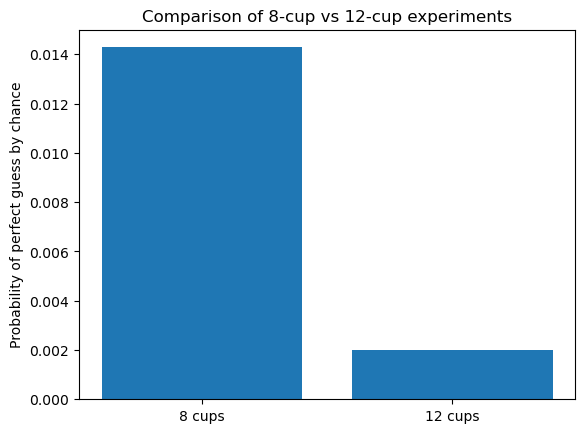

In [9]:
original_prob = 1/70      # 8 cups, 4 milk-first
extended_prob = 1/495     # 12 cups, 4 milk-first

plt.bar(["8 cups", "12 cups"], [original_prob, extended_prob])
plt.ylabel("Probability of perfect guess by chance")
plt.title("Comparison of 8-cup vs 12-cup experiments")
plt.show()


As the total number of cups increases, the number of possible 4 cup combinations increases. Therefore, the chance of randomly choosing the exact four milk first cups decrease and the probability decreases.

if the lady identified all four milk first cups correctly the p-value is 0.020. This is less than the significance value of a = 0.05, --> therefore she likely has a special ability to distinguish the tea. 

**Null Hypothesis(Ho):** The lady is guessing and has no special ability

**Alternative Hypothesis(H1):** The lady can correctly identify the milk-first cups better than chance 

significance level: a = 0.05
p value: 0.020

The p-value(0.020) is less than the significance value 0.05, therefore the null hypothesis is rejected. The result shows strong evidence that the lady has an ability to distinguish between the cups of tea. 



Both experiments reject the null hypothesis at the 0.05 significance level. However, the 12 cup experiment shows much stronger evidence that the lady is not choosing by random chance, with a p-value of 0.002 compared to 0.014 in the 8 cup experiment. If the significance level was reduced to 0.01 to reduce the risk of a type 1 error, the 12 cup result would still be significant but the 8 cup result would no longer meet the threshold and the null hypothesis would not be rejected for the 8 cup test which could lead to a type 2 error of not detecting an ability when one exists.  

***
***

### **Problem 2: Normal Distribution:**

*Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.*

<hr style="border-top: 2px dashed gray; border-bottom: none;">


**Aim:**

The aim of this study is to show how sample standard deviations differ from the population standard deviation when taking many small samples from a standard normal distribution (mean=0, SD=1). The sample standard deviation (n-1, ddof=1) and population standard deviation(n, ddof=0) are calculated for 100,000 samples with sample size=10 and visualised using histograms.




**Background:**

Standard Deviation(SD): measures how much values in a dataset spread out from the mean. A larger SD indicates the value are more spread out and vary alot while a smaller SD shows the values are closer to the mean. SD is a measure of variability in the data. 

A sampling distribution shows how a statistic such as the mean or standard deviation varies across repeated samples from the same population. Each sample gives a slightly different result and plotting the results from many samples allows visualisation of this variability.

When calculating SD for a sample, the population mean is unknown so the sample mean is used instead. This causes deviations from the sample mean to be slightly smaller than deviations from the true population mean. Using n(ddof=0) to calculate SD tends to underestimate the population variability, especially for small samples. Bessels correction, dividing by n-1 (ddof=1) corrects this bias, making the sample SD an unbiased estimator of the population SD.

 


https://en.wikipedia.org/wiki/Bessel%27s_correction



https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import numpy as np
data = np.random.normal(size=100000)
data

array([-1.25402237,  0.77227363,  1.5131044 , ...,  0.37537958,
       -0.92243829,  0.30619005])

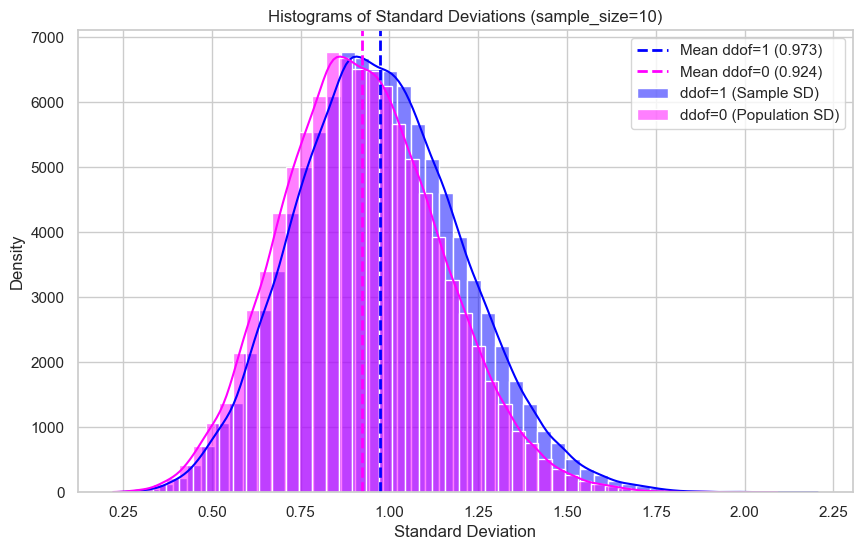

In [12]:


number_samples = 100000
sample_size = 10

samples = np.random.normal(loc=0, scale=1, size=(number_samples, sample_size))

# Calculate standard deviations
std_ddof1 = np.std(samples, axis=1, ddof=1)  # Sample SD
std_ddof0 = np.std(samples, axis=1, ddof=0)  # Population SD

# Calculate means
mean_ddof1 = np.mean(std_ddof1)
mean_ddof0 = np.mean(std_ddof0)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot histograms with KDE
sns.histplot(std_ddof1, bins=50, color='blue', label='ddof=1 (Sample SD)', kde=True, alpha=0.5)
sns.histplot(std_ddof0, bins=50, color='magenta', label='ddof=0 (Population SD)', kde=True, alpha=0.5)

# Add mean lines  
plt.axvline(mean_ddof1, color='blue', linestyle='--', linewidth=2, label=f'Mean ddof=1 ({mean_ddof1:.3f})')
plt.axvline(mean_ddof0, color='magenta', linestyle='--', linewidth=2, label=f'Mean ddof=0 ({mean_ddof0:.3f})')

plt.xlabel('Standard Deviation')
plt.ylabel('Density')
plt.title('Histograms of Standard Deviations (sample_size=10)')
plt.legend()
plt.show()


The sample SD(ddof=1) is slightly wider and right skewed, showing that some sample SD's are larger than the population SD.
-   Population SD(ddof=0) is slightly narrower and slightly left skewed which shows how population SD underestimates variability in smaller samples. 

The histograms overlap but the peak of the sample SD distribution is slightly closer to the true population SD.  The true population SD is 1 for a standard normal distribution. The peak of the sample SD is closer to the true SD of 1 than the population SD. This shows that using n-1 gives a sample SD a more accurate estimate of the population SD. The population SD is slightly left of the true value, showing it underestimates variability in small samples. 


Larger sample sizes reduce natural variability in the sample SDs. The histograms would become narrower and more centered around the true population SD of 1. This is because a larger sample gives a better estimate of the population mean, reducing bias and variability. 





Even with Bessels correction, individual sample SD's still vary around the true SD due to natural sampling variability. The standard error is the standard deviation of a statistics sampling distribution and measures how much a statistic  varies from sample to sample. Larger samples reduce the standard error, giving more reliable estimates.

***
***

### **Problem 3: t-Tests**

*A type II error occurs when a test fails to reject the null hypothesis even though it is false. For each mean difference* *d* *= 0, 0.1, 0.2, … , 1.0, repeat the following simulation 1,000 times:*

*1.Draw two samples of size 100, one from the standard normal distribution and one from the normal distribution with mean* *d* *and standard deviation 1.*

*2.Run an independent samples t-test on the two samples, rejecting the null hypothesis if the p-value is less than 0.05*

*3.Record the proportion of times the null hypothesis is not rejected.*

*Plot this proportion against d, and explain how the type II error rate changes as the difference in means increases.*

<hr style="border-top: 2px dashed gray; border-bottom: none;">





-   two independent groups
-   significance level: 0.05

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

Type II error is when you fail to detect a difference even though their really is one. 

In [ ]:
# import libraries.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [ ]:
sample_size = 100
alpha = 0.05 

# calculate mean differences.
meandiff = np.arange(0.0, 1.1, 0.1)


https://numpy.org/doc/stable/user/basics.creation.html

In [ ]:


type2_errors = []

# run simulation
for d in meandiff:
    type2_count = 0
    for _ in range(1000):
        group1 = np.random.normal(loc=0, scale=1, size=sample_size) # 
        group2 = np.random.normal(loc=d, scale=1, size=sample_size)
        tstat, pvalue = stats.ttest_ind(group1, group2)
        if pvalue >= alpha:
            type2_count += 1
    type2_errors.append(type2_count / 1000)

print("Type 2 Error Rates:", type2_errors)



Type 2 Error Rates: [0.948, 0.882, 0.691, 0.463, 0.191, 0.047, 0.012, 0.001, 0.0, 0.0, 0.0]


-   Group 1 mean = 0 
-   Group 2 mean = d (0.0-1.0)


By changing d, from 0.0 - 1.0:
-   show different effect sizes (true differences in population means). 
-   when d=0, the null hypothesis is true --> no difference between groups (no effect)
-   when d>0, the null hypothesis is false --> there is a difference (large effect groups are far apart)

(Effect size =  distance between two group means. Bigger distance =  bigger effect)

In [22]:
# plot table pandas DataFrame
import pandas as pd
type2_table = pd.DataFrame({'Mean Difference': meandiff, 'Type 2 Error Rate(d)': type2_errors, 'power(1-β)': 1 - np.array(type2_errors) })
type2_table

,Mean Difference,Type 2 Error Rate(d),power(1-β)
0,0.0,0.948,0.052
1,0.1,0.882,0.118
2,0.2,0.691,0.309
3,0.3,0.463,0.537
4,0.4,0.191,0.809
5,0.5,0.047,0.953
6,0.6,0.012,0.988
7,0.7,0.001,0.999
8,0.8,0.000,1.000
9,0.9,0.000,1.000


https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html

-   As the mean difference increases, the Type 2 error rate decreases, with a higher statistical power to detect a true effect. 

-   The Type II error rate is the probability that a statistical test fails to reject the null hypothesis even though the null hypothesis is false. 

-   Type 2 errors have an inverse relationship with the statistical power of a test. High statistical power will have low type 2 error.

Statistical power is the probability that the test correctly detects a difference when there really is one.

Power = 1 - &beta;

*&beta; -> Type II error rate -> failing to detect a true effect*



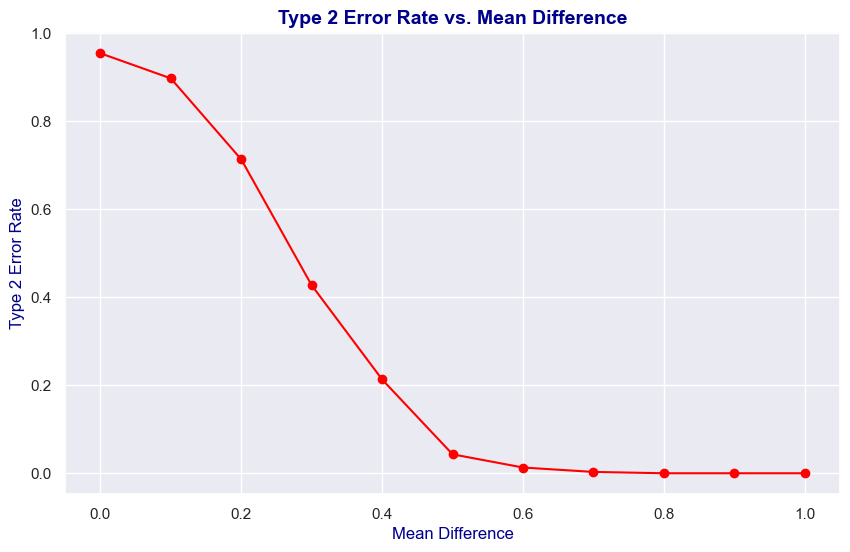

In [26]:
# plot 

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(meandiff, type2_errors, color='red', marker='o')
ax.set_xlabel('Mean Difference', color='darkblue')
ax.set_ylabel('Type 2 Error Rate', color='darkblue')
ax.set_title('Type 2 Error Rate vs. Mean Difference', fontsize=14, fontweight='bold', color='darkblue')
plt.show()


-   As the mean difference between the two groups increases, the overlap between them decreases. 
-   when mean difference is small, there is significant overlap, making it more difficult for the ttest to detect a true difference. 
-   Therefore, the Type II error rate is high. (failing to reject a false null hypothesis)
-   when d=0, the null hypothesis is true and the test correctly fails to reject it in approx 95% of repeated samples, which is consistent with the significance level of &alpha;
= 0.05
-   as the meana difference increases, the distributions become more separated, making it easier for the ttest to detect a difference. 
-   Therefore the Type II error rate decreases and is close to zero for larger mean differences while the stat power (probability of correctly detecting a true effect) increases close to 1

***

### **Problem 4: ANOVA**

Generate three independent samples, each of size 30, from normal distributions with means 0, 0.5, and 1, each with standard deviation 1.

-   Perform a one-way ANOVA to test whether all three means are equal.
-   Perform three independent two-sample t-tests: samples 1 vs 2, 1 vs 3, and 2 vs 3.
-   Compare the conclusions.
-   Write a short note on why ANOVA is preferred over running several t-tests.

<hr style="border-top: 2px dashed gray; border-bottom: none;">
